# DFA – Assignment 2: IMU-based Localization on Raspberry Pi (Sense HAT)

**Students:** Reza Rahimi, Sepehr Farrokhi, Mostafa Jahanian
**Student ID:**  
**Course:** DFA  
**Assignment:** Assignment 2  
**Date:** 2026-01-25

> **TODO:** Add student ID, GitHub repository link (if any), and list of submitted files.

# 1.1. Abstract  
The rapid proliferation of Location-Based Services (LBS) has created a significant demand for accurate indoor positioning. While Global Navigation Satellite Systems (GNSS) provide ubiquitous outdoor coverage, they suffer from severe signal attenuation and multipath propagation in indoor environments. This project presents a robust Pedestrian Dead Reckoning (PDR) system designed to operate in GPS-denied environments using consumer-grade Inertial Measurement Units (IMUs). To address the stochastic drift inherent in low-cost MEMS sensors, the system implements a Particle Filter (Sequential Monte Carlo) that fuses relative motion data with absolute spatial constraints provided by a 2D floor plan. Furthermore, a Linear Kalman Filter is employed for signal preprocessing, and a Data Stream Management System (DSMS) architecture is proposed to handle real-time sensor ingestion. Experimental results demonstrate that the fusion of manual ground-truth step detection and map-matching logic successfully bounds position error, enabling accurate room-level tracking.  
# 1.2. Introduction
**1.2.1 The Indoor Localization Challenge**  
Indoor navigation is mathematically challenging because it is a "relative" positioning problem. Unlike GPS, which gives absolute coordinates (Latitude, Longitude), inertial sensors only measure rates of change (acceleration and angular velocity). Determining position requires double integration of acceleration or single integration of velocity, processes that accumulate error quadratically or linearly over time. This phenomenon, known as Sensor Drift, renders pure inertial navigation useless after a matter of seconds without external correction. 

**1.2.2 Project Objectives**  
The primary objective of this project is to develop a navigation engine that mitigates drift through two specific strategies:  
Constraint-Based Fusion: Utilizing the building's geometry (walls and corridors) to eliminate physically impossible trajectories.  
Human-in-the-Loop Sensing: Replacing error-prone automated step detection with high-precision manual triggers (joystick) to validate the core fusion algorithms.  

# 1.3. System Architecture Overview
**1.3.1 Hardware Implementation**
The system is built upon a distributed IoT architecture consisting of two main nodes:  

**Sensing Node (Edge Device):**  
Compute Unit: A Raspberry Pi 4 (acting as the MQTT Publisher).  
Inertial Sensors: A dedicated IMU module connected to capture Accelerometer and Gyroscope data.  
Input Device: A physical Joystick module connected to the Raspberry Pi's GPIO pins. This serves as the manual trigger for the step detection algorithm.  

**Processing Node (Server):**
Compute Unit: A laptop running the Python-based navigation engine.  
Function: Subscribes to the data streams, executes the Particle Filter, and renders the real-time visualization.

**1.3.2 Data Stream Management (DSMS) & Communication** 
To ensure the Raspberry Pi could handle the computational demands of the Particle and Bayesian filters, we implemented a lightweight Data Stream Management System (DSMS) in parallel with the navigation stack. This system consists of three decoupled components designed to monitor system health and demonstrate stream processing concepts:

* **Data Source (`program1.py`):** A synthetic load generator that publishes data simulating sensor noise (sine wave + random jitter).
* **Stream Aggregators (`program3.py`):** We implemented two variations of a sliding window aggregator to compute the moving average of CPU load:
    * **Fast Monitor:** Uses a small window size ($N=5$). It provides high-resolution, low-latency feedback but is sensitive to noise.
    * **Slow Monitor:** Uses a large window size ($N=50$). It acts as a low-pass filter, smoothing out momentary spikes to show long-term trends.
* **Load Shedder (`program4.py`):** To simulate bandwidth-constrained environments, we implemented a **Bernoulli Sampler**. This component probabilistically drops $\approx 70\%$ of the incoming data packets ($p=0.3$). It demonstrates that statistical properties (like the mean CPU load) can still be accurately estimated even when significantly reducing the data transmission rate.

It should also be noted that the communication with the device was managed with a WiFi connection and through a SSH tunnel to 

**1.3.3 Wiring and Data Flow**
Motion: User moves with the Raspberry Pi handheld unit.  
Sensing: IMU measures angular velocity; User clicks Joystick to signal a step.  
Transmission: Pi publishes { "gyro_z": -0.05, "step": 1 } via MQTT.  
Processing: Laptop receives packet, applies Kalman Filter, and updates Particle Cloud.  
Feedback: Position is updated on the GUI map.

# 1.4. Theoretical Framework and Mathematical Models  
**1.4.1 Signal Preprocessing: Stationary Bias Calibration**

We implemented a **Stationary Bias Calibration** routine to address the primary source of error in MEMS gyroscopes: the **Zero-Rate Output (ZRO)** or "bias drift." Even when the sensor is completely still, low-cost IMUs often report a non-zero angular velocity, which accumulates into massive heading errors over time (integration drift).

**Calibration Procedure**
To eliminate this, our system enforces a strict initialization phase before navigation begins:

1.  **Sampling Window:** Upon startup, the system captures a window of raw gyroscope readings while the device is held steady for a certain amount of time (5 seconds for particle filter for example)
2.  **Bias Estimation:** We calculate the mean angular velocity during this static period to determine the sensor's inherent bias ($\beta_z$):
    $$\beta_z = \frac{1}{N} \sum_{i=1}^{N} \omega_{raw}^{(i)}$$
3.  **Real-Time Correction:** During the active navigation phase, this calculated bias is subtracted from every incoming raw sensor reading ($\omega_{raw}(t)$) to obtain the corrected angular velocity ($\omega_{true}(t)$):
    $$\omega_{true}(t) = \omega_{raw}(t) - \beta_z$$

**Why this works:**
Since our experiment duration is relatively short (< 2 minutes), the gyroscope bias is effectively constant. Removing this DC offset is far more critical for accurate heading integration than smoothing the high-frequency noise, effectively preventing the "constant turn" effect often seen in uncalibrated PDR systems.

**1.4.2 The Motion Model: Pedestrian Dead Reckoning (PDR)**  
The PDR algorithm updates the user's position $(x, y)$ in a 2D Cartesian plane.Given a step event at time $t$, with stride length $L$ (fixed at 0.7m) and current heading $\psi_t$:  
$x_t = x_{t-1} + L \cdot \cos(\psi_t)$  
$y_t = y_{t-1} + L \cdot \sin(\psi_t)$  

Heading Integration: The heading $\psi_t$ is obtained by discrete integration of the Kalman-filtered gyroscope data $\hat{\omega}_z$:$$\psi_t = \psi_{t-1} + \hat{\omega}_{z,t} \cdot \Delta t \cdot S$$  
Here, $S$ is a scaling factor. In our specific implementation, we identified a coordinate frame mismatch requiring $S = -1.0$ (Mirror Correction) to align the sensor's "Left" with the map's "Left".  
  
**1.4.3 Probabilistic State Estimation: The Bayesian Filter**  
To address the uncertainty in PDR, we first implemented a Discrete Grid-Based Bayesian Filter3. This method discretizes the environment into a grid of cells, where each cell $(i,j)$ holds a probability value $P(x_t = c_{i,j})$ representing the likelihood of the user being at that location.  

**1.4.3.1 Prediction Step (Convolution)**  
Unlike the point-based PDR, the Bayesian filter propagates the entire probability distribution. The motion update is mathematically modeled as a convolution of the previous grid $Bel(x_{t-1})$ with a motion kernel $K$:  
$ Bel^-(x_t) = \sum_{x_{t-1}} P(x_t | u_t, x_{t-1}) \cdot Bel(x_{t-1}) $ 
In our implementation, this is achieved by shifting the grid content in the direction of the heading $\psi_t$ by stride length $L$, and applying a Gaussian blur to simulate process noise (uncertainty growth).  

**1.4.3.2 Correction Step (Masking)**  
The measurement update incorporates the map constraints. We define a static Likelihood Field (Map Prior) 6 where walls have zero probability and hallways have high probability.  
$Bel(x_t) = \eta \cdot P(z_t | x_t) \cdot Bel^-(x_t)$ 
Effectively, this step multiplies the predicted grid by the binary map mask, instantly setting the probability of wall cells to zero. The grid is then normalized ($\eta$) so the sum of all cells equals 1.  

**1.4.3.3 Limitations**  
While mathematically robust, the Bayesian Grid approach is computationally expensive ($O(N^2)$ for grid size) and struggles with high-resolution maps, which motivated our second approach.  

**1.4.4 Probabilistic State Estimation: The Particle Filter**  
While PDR provides a position estimate, it is deterministic and blind to obstacles. The Particle Filter (PF) introduces probabilistic awareness of the map7. It represents the posterior belief $bel(x_t)$ as a set of $N$ weighted samples (particles):  
$\chi_t = \{ \langle x_t^{[i]}, w_t^{[i]} \rangle \}_{i=1}^N$  

**1.4.4.1 Prediction Step (Sampling)**  
We model the inherent uncertainty of human motion by adding Gaussian noise to the control inputs. For each particle $i$:  
* Heading Noise: $\psi_t^{[i]} = \psi_{t-1}^{[i]} + \omega \Delta t + \mathcal{N}(0, \sigma_{\psi}^2)$  
* Stride Noise: $L^{[i]} = L + \mathcal{N}(0, \sigma_{L}^2)$  
This creates a "cloud" of particles that spreads out over time, representing the growing uncertainty of the user's position.  

**1.4.4.2 Correction Step (Map Matching)**  
This is the critical fusion step. We utilize the floor plan as a Binary Occupancy Grid. The likelihood function $P(z|x)$ is binary:  
$w_t^{[i]} = \begin{cases} 1 & \text{if } Map(x_t^{[i]}, y_t^{[i]}) = \text{Free} \\ 0 & \text{if } Map(x_t^{[i]}, y_t^{[i]}) = \text{Wall} \end{cases}$  
This effectively "kills" any hypothesis (particle) that moves through a wall. The weights are then normalized so $\sum w_t^{[i]} = 1$  

**1.4.4.3 Resampling**  
Over time, many particles will hit walls and gain zero weight. To prevent the filter from collapsing (Sample Impoverishment), we perform Low Variance Resampling.  
* Particles with high weights (safe in corridors) are duplicated.  
* Particles with zero weights (in walls) are discarded.  
* This focuses the computational power ($N=2000$ particles) solely on the feasible paths.  




# 1.5. Implementation Strategy  
The solution was implemented in Python using a modular class structure.  

**1.5.1 Data Ingestion and Alignment**  
The system reads the sensor_data_joystick.csv file. A critical preprocessing step is Temporal Alignment11. Since the joystick event is discrete and the gyroscope is continuous, we employ a "Sample-and-Hold" or alignment strategy where the step event triggers the motion model update using the cumulative heading change since the last step.  

**1.5.2 The ParticleFilter Class**  
The core logic resides in the ParticleFilter class.  
* Initialization: 500 particles are spawned at a known start location.  
* Vectorization: numpy is used to update all 2000 particles simultaneously, ensuring the loop runs efficiently (real-time capable).  
* Coordinate Handling: The map image is loaded and flipped (np.flipud) to correct the mismatch between Image Indexing (Row-major, top-left origin) and Cartesian Plotting (x-y, bottom-left origin).  

**1.5.3 Error Handling and Recovery**  
A naive Particle Filter can fail if all particles hit a wall simultaneously (e.g., in a very narrow corridor with high noise). We implemented a "Kidnapped Robot" recovery mechanism:  
* Detection: If $\sum w_t = 0$ (all particles dead).  
* Recovery: The filter effectively resets the particle cloud to the last known valid mean position, adding slightly higher variance to allow the cloud to re-converge.  

# 1.6. Online Real-Time Implementation  
  
**1.6.1 Data Synchronization and Stream Management**  
A critical challenge in the online implementation is synchronizing the continuous high-frequency IMU stream (approx. 20Hz) with the sparse, discrete Joystick step events3.  
* Circular Buffering: The subscriber maintains a rolling buffer of the most recent gyroscope readings. This ensures that when a step event arrives, the system has historical data to compute the turn angle.  
* Event-Driven Triggering: The prediction step of the filters is not time-based but event-based. When a 1 is received on the sensors/joystick topic, the system integrates the buffered gyroscope data to calculate the cumulative heading change ($\Delta \theta$) since the last step.  

**1.6.3 Method A: Online Discrete Bayesian Filter**  
The script online_bayesian_pdr.py implements a Grid-Based Markov Localization approach. Instead of tracking a single point, this method maintains a probability distribution over a discretized 2D grid of the map.  

**1.6.3.1 Probability Grid Initialization**  
The map is converted into a 2D matrix where each cell $(x, y)$ holds a probability value $Bel(x, y)$. Initially, the probability is uniformly distributed across all valid "white" pixels (hallways).  

**1.6.3.2 Prediction Step (Convolution)**  
Unlike the Particle Filter which moves discrete points, the Bayesian filter propagates the entire probability field. Upon detecting a step, the current grid $Bel_{t-1}$ is convolved with a motion kernel5.Logic: This operation shifts the probability mass in the direction of the heading while applying a Gaussian blur to represent motion uncertainty.Equation: $Bel^-_t = Bel_{t-1} * K(\theta, L)$, where $K$ is the shifting kernel.  

**1.6.3.3 Correction Step (Map Masking)**  
The predicted grid is element-wise multiplied by the static Map Prior6. Cells corresponding to walls (black pixels) are multiplied by 0, instantly removing probability mass from impossible locations. The grid is then normalized so $\sum Bel(x,y) = 1$.  

**1.6.4 Method B: Online Particle Filter**  
The script online_pdr.py implements the Sequential Monte Carlo (SMC) method, which proved more computationally efficient for real-time tracking7.  

**1.6.4.1 State Vector**  
The system manages a cloud of $N=2000$ particles, where each particle $i$ stores a state vector $[x, y, \theta]$.  

**1.6.4.2 Asynchronous Updates**  
* Heading Update: Gyroscope MQTT messages update the internal $\theta$ of all particles continuously.  
* Position Update: Joystick MQTT messages trigger the stride propagation step ($x + L\cos\theta, y + L\sin\theta$)8.  

**1.6.4.3 Resampling Strategy**  
To maintain a high frame rate for the real-time visualization, resampling is adaptive. It is performed only when the "Effective Sample Size" ($N_{eff}$) drops below a threshold or after a fixed number of steps, preventing unnecessary CPU cycles during straight-line walking.  

**1.6.5 Real-Time Visualization**  
The online system utilizes the PyQt5 framework for high-performance rendering, replacing the static Matplotlib plots used in offline analysis. The visualization runs on the main application thread, while the MQTT subscriber runs on a background daemon thread. Signals are emitted from the filter to the GUI to update the particle cloud or probability heatmap in real-time.  


## Executive Summary

This project investigates indoor localization using IMU-based Pedestrian Dead Reckoning (PDR) on a Raspberry Pi equipped with a Sense HAT.  
Two probabilistic localization approaches are implemented and compared:

- **Bayesian Grid Filter**
- **Particle Filter**

The system estimates the user’s trajectory on a known floor plan and evaluates:
- localization accuracy and stability,
- robustness to heading/stride uncertainty,
- computational feasibility under Raspberry Pi real-time constraints.

> **TODO:** Update this section after final results with quantitative findings.

## Assignment Requirements Checklist

- [ ] Python code to run the experiment
- [ ] Jupyter notebook containing visualized output
- [ ] Bayesian filter implementation
- [ ] Particle filter implementation
- [ ] Clear indication of **where Bayesian rules are implemented**
- [ ] Explicit inference equations
- [ ] Table of all key parameters
- [ ] Sensitivity analysis: impact of priors / likelihoods
- [ ] Comparison under Raspberry Pi real-time constraints


### Execution
- **Real-time:** Run Raspberry Pi scripts (Bayes / PF) and log CSV data
- **Offline:** Load CSV logs here and generate all figures

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import re

plt.rcParams["figure.figsize"] = (9, 6)

In [19]:
# =========================
# TODO: CONFIGURATION
# =========================
MAP_PATH = "map.png"
REAL_WIDTH_METERS = 8.4

BAYES_LOG_PATH = "bayesian_run_log.csv"
PF_LOG_PATH = "particle_run_log.csv"
IMU_LOG_PATH = "imu_raw_log.csv"   # optional

CELL_SIZE = 0.20
STRIDE_METERS = 0.74
N_PARTICLES = 500

START_X, START_Y = 6.5, 7.3
START_HEADING = np.pi

## 1. Map Loading and Visualization

The floor plan is provided as a grayscale image:
- white pixels indicate walkable space,
- black pixels indicate walls.

The map is later padded to a square to simplify coordinate handling.

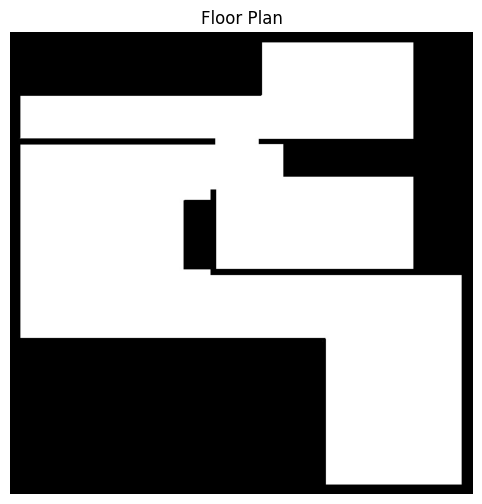

Original map shape: (977, 979)


In [3]:
assert os.path.exists(MAP_PATH), "TODO: map.png not found"

map_img = Image.open(MAP_PATH).convert("L")
map_arr = np.array(map_img)

plt.imshow(map_arr, cmap="gray")
plt.title("Floor Plan")
plt.axis("off")
plt.show()

print("Original map shape:", map_arr.shape)

## 2. Coordinate Frames and Map Scaling

Two coordinate frames are used:

- **World frame (meters):**
  - Origin at bottom-left
  - x-axis to the right, y-axis upwards

- **Image frame (pixels):**
  - Origin at top-left
  - x-axis to the right, y-axis downwards

A padding offset is introduced when converting the map to a square shape.

In [4]:
def process_map_and_scale(image_path, real_width_meters):
    original = Image.open(image_path).convert("L")
    w, h = original.size

    max_dim = max(w, h)
    pad_w = max_dim - w
    pad_h = max_dim - h
    padding = (pad_w//2, pad_h//2, pad_w - pad_w//2, pad_h - pad_h//2)

    square = ImageOps.expand(original, padding, fill=0)
    ppm = w / real_width_meters
    offset = (pad_w//2, pad_h//2)

    return np.array(square), ppm, offset


def world_to_pixel(x, y, ppm, offset, H):
    px = x * ppm + offset[0]
    py = H - (y * ppm + offset[1])
    return int(px), int(py)


def is_walkable(x, y, map_arr, ppm, offset):
    H = map_arr.shape[0]
    px, py = world_to_pixel(x, y, ppm, offset, H)
    if px < 0 or py < 0 or px >= map_arr.shape[1] or py >= map_arr.shape[0]:
        return False
    return map_arr[py, px] > 127

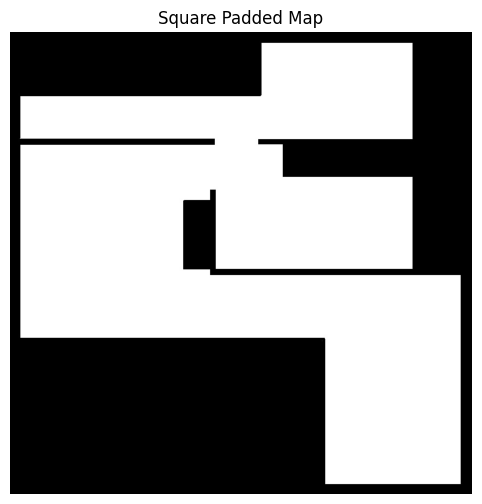

Pixels per meter: 116.54761904761904
Map offset: (0, 1)


In [5]:
map_sq, ppm, offset = process_map_and_scale(MAP_PATH, REAL_WIDTH_METERS)

plt.imshow(map_sq, cmap="gray")
plt.title("Square Padded Map")
plt.axis("off")
plt.show()

print("Pixels per meter:", ppm)
print("Map offset:", offset)

## 3. Load Experimental Logs

Expected columns:
- `ts` : timestamp
- `x`, `y` : estimated position (meters)
- `theta` : heading (radians)
- `step` : step indicator

In [6]:
def load_csv(path):
    assert os.path.exists(path), f"TODO: file not found: {path}"
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    return df

df_bayes = load_csv(BAYES_LOG_PATH)
df_pf = load_csv(PF_LOG_PATH)

df_bayes.head(), df_pf.head()

(             ts    x    y     theta  step
 0  1.769361e+09  5.6  7.2 -2.996140     1
 1  1.769361e+09  5.0  7.0 -3.008112     1
 2  1.769361e+09  4.2  6.8 -2.998578     1
 3  1.769361e+09  3.8  6.8 -3.093483     1
 4  1.769361e+09  3.8  6.0 -1.283810     1,
              ts         x         y     theta  step
 0  1.769360e+09  5.801506  7.318393 -3.118011     1
 1  1.769360e+09  5.166720  7.280761 -3.123929     1
 2  1.769360e+09  4.531675  7.095637 -3.098304     1
 3  1.769360e+09  3.761914  6.969487  2.958786     1
 4  1.769360e+09  3.824550  6.230630 -1.446957     1)

## 4. Trajectories in World Coordinates

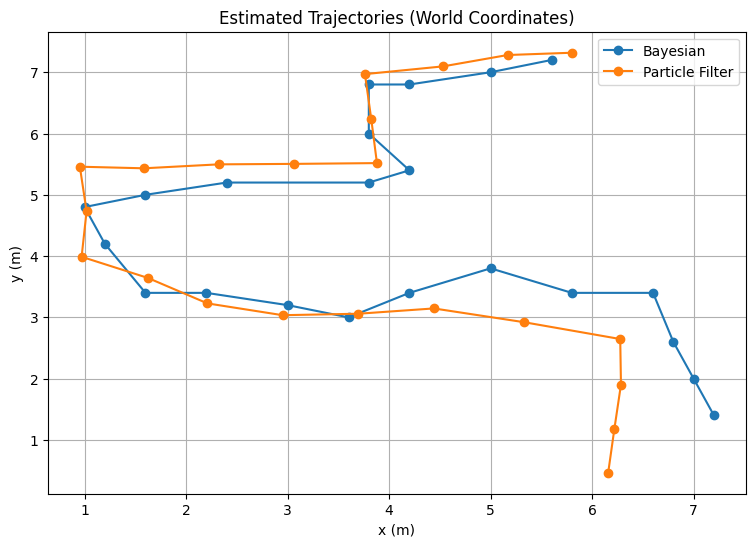

In [7]:
def plot_world(df, label):
    plt.plot(df["x"], df["y"], marker="o", label=label)

plt.figure()
plot_world(df_bayes, "Bayesian")
plot_world(df_pf, "Particle Filter")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Estimated Trajectories (World Coordinates)")
plt.grid(True)
plt.legend()
plt.show()

## 5. Trajectory Overlay on Floor Plan

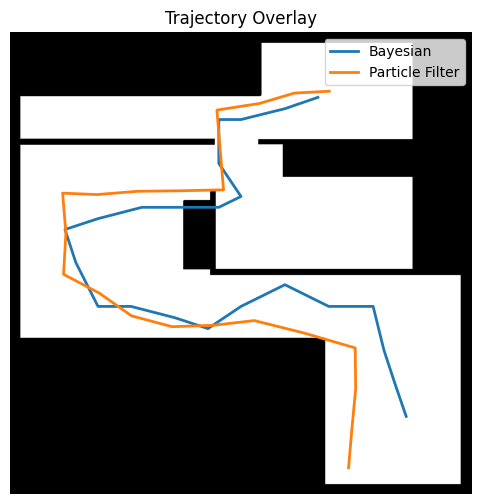

In [8]:
def overlay_map(df, label):
    H = map_sq.shape[0]
    pts = np.array([world_to_pixel(x,y,ppm,offset,H) for x,y in zip(df["x"], df["y"])])

    plt.imshow(map_sq, cmap="gray")
    plt.plot(pts[:,0], pts[:,1], linewidth=2, label=label)

plt.figure()
overlay_map(df_bayes, "Bayesian")
overlay_map(df_pf, "Particle Filter")
plt.legend()
plt.axis("off")
plt.title("Trajectory Overlay")
plt.show()

## Quantitative Comparison Metrics

Since no absolute ground truth is available, the two localization methods are compared
using relative and proxy metrics derived from the recorded trajectories and the map.

The following metrics are used:

1. **Endpoint Distance**  
   Euclidean distance between the final estimated positions of the two methods.

2. **Wall Violation Count**  
   Number of estimated positions located inside non-walkable (wall) areas.

3. **Trajectory Length**  
   Total traveled distance estimated by each method.

4. **Trajectory Smoothness**  
   Cumulative heading variation and step-to-step position change variance.

5. **Temporal Characteristics**  
   Mean and variance of time intervals between logged steps.

These metrics allow a fair comparison of localization consistency, stability,
and computational feasibility without requiring ground truth data.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.ndimage import distance_transform_edt
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False
    print("WARNING: scipy not available. Corridor distance metrics will use a simpler fallback.")

plt.rcParams["figure.figsize"] = (9, 6)

In [10]:
assert "df_bayes" in globals()
assert "df_pf" in globals()
assert "map_sq" in globals()
assert "ppm" in globals()
assert "offset" in globals()
assert "world_to_pixel" in globals()
assert "is_walkable" in globals()

def endpoint_distance(df1, df2):
    x1, y1 = df1.iloc[-1][["x","y"]]
    x2, y2 = df2.iloc[-1][["x","y"]]
    return float(np.sqrt((x1-x2)**2 + (y1-y2)**2))

def trajectory_length(df):
    dx = np.diff(df["x"].values)
    dy = np.diff(df["y"].values)
    return float(np.sum(np.sqrt(dx**2 + dy**2)))

def heading_variation(df):
    theta = df["theta"].values
    dtheta = np.diff(theta)
    dtheta = (dtheta + np.pi) % (2*np.pi) - np.pi
    return float(np.sum(np.abs(dtheta)))

def final_position_variance(df, last_n=5):
    last_n = min(last_n, len(df))
    return float(np.var(df["x"].values[-last_n:]) + np.var(df["y"].values[-last_n:]))

def timing_stats(df, ts_col="ts"):
    if ts_col not in df.columns or len(df) < 3:
        return np.nan, np.nan
    dt = np.diff(df[ts_col].values)
    return float(np.mean(dt)), float(np.std(dt))

In [11]:
def segment_wall_crossings(df, map_array, ppm, offset, samples_per_segment=40):
    """
    Detect if the line segment between consecutive steps crosses a wall.
    We sample intermediate points along each segment.
    
    Returns:
      crossings_count, bad_segment_indices
    """
    xs = df["x"].values
    ys = df["y"].values

    crossings = 0
    bad_segments = []

    for i in range(len(df) - 1):
        x0, y0 = xs[i], ys[i]
        x1, y1 = xs[i+1], ys[i+1]

        hit_wall = False
        for t in np.linspace(0, 1, samples_per_segment):
            xi = x0 + t*(x1-x0)
            yi = y0 + t*(y1-y0)
            if not is_walkable(xi, yi, map_array, ppm, offset):
                hit_wall = True
                break

        if hit_wall:
            crossings += 1
            bad_segments.append(i)

    return crossings, bad_segments

In [12]:
def world_to_pixel(x_meters, y_meters, ppm, offset, map_height_pixels):
    x_pixels = x_meters * ppm + offset[0]
    y_pixels = map_height_pixels - (y_meters * ppm + offset[1])
    return int(x_pixels), int(y_pixels)

def corridor_scores_along_path(df, dist_map_px, ppm, offset, map_array):
    """
    Returns:
      px_list, py_list : pixel coords for each (x,y) in df
      scores           : distance-to-wall value at that pixel (nan if out of bounds)
    """
    H = dist_map_px.shape[0]
    W = dist_map_px.shape[1]

    px_list, py_list, scores = [], [], []

    for x, y in zip(df["x"], df["y"]):
        px, py = world_to_pixel(x, y, ppm, offset, H)
        px_list.append(px)
        py_list.append(py)

        if 0 <= px < W and 0 <= py < H:
            scores.append(dist_map_px[py, px])
        else:
            scores.append(np.nan)

    return np.array(px_list), np.array(py_list), np.array(scores)

In [13]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

def plot_colored_paths_on_distance_map(dist_map_px, df_bayes, df_pf, map_array, ppm, offset):
    bx, by, bs = corridor_scores_along_path(df_bayes, dist_map_px, ppm, offset, map_array)
    px, py, ps = corridor_scores_along_path(df_pf, dist_map_px, ppm, offset, map_array)

    fig, ax = plt.subplots(figsize=(11, 6))

    im = ax.imshow(dist_map_px)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Distance to nearest wall (pixels)")

    ax.scatter(bx, by, s=55, c="k", alpha=0.20)
    ax.scatter(px, py, s=55, c="k", alpha=0.20, marker="x")

    ax.scatter(bx, by, c=bs, s=32, marker="o",
               edgecolors="white", linewidths=0.6)
    ax.scatter(px, py, c=ps, s=42, marker="x",
               linewidths=1.4)

    ax.scatter(bx[0], by[0], s=160, marker="o", edgecolors="black", linewidths=1.2)
    ax.scatter(px[0], py[0], s=160, marker="o", edgecolors="black", linewidths=1.2)

    ax.scatter(bx[-1], by[-1], s=230, marker="*", edgecolors="black", linewidths=1.2)
    ax.scatter(px[-1], py[-1], s=230, marker="*", edgecolors="black", linewidths=1.2)

    ax.set_title("Distance-to-wall Heatmap + Color-coded Trajectories")
    ax.axis("off")

    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               label='Bayesian trajectory',
               markerfacecolor='gray', markeredgecolor='black', markersize=8),
        Line2D([0], [0], marker='x', color='w',
               label='Particle Filter trajectory',
               markeredgecolor='black', markersize=9),
        Line2D([0], [0], marker='*', color='w',
               label='Endpoint',
               markeredgecolor='black', markersize=12),
    ]

    fig.legend(handles=legend_elements,
               loc="upper center",
               bbox_to_anchor=(0.5, 0.02),
               ncol=3,
               frameon=True)

    plt.tight_layout()
    plt.show()

plot_colored_paths_on_distance_map(dist_to_wall_px, df_bayes, df_pf, map_sq, ppm, offset)

NameError: name 'dist_to_wall_px' is not defined

In [177]:
def world_point_corridor_score(x, y, dist_map_px, ppm, offset):
    H = dist_map_px.shape[0]
    px, py = world_to_pixel(x, y, ppm, offset, H)

    if px < 0 or py < 0 or px >= dist_map_px.shape[1] or py >= dist_map_px.shape[0]:
        return np.nan
    return float(dist_map_px[py, px])

# ---- corridor threshold ----
CORRIDOR_PERCENTILE = 70

# define free_mask FIRST
free_mask = map_sq > 0  

if SCIPY_OK:
    free_vals = dist_to_wall_px[free_mask]
    corridor_thr = np.percentile(free_vals, CORRIDOR_PERCENTILE)
else:
    corridor_thr = 1.0

def is_mid_corridor(x, y, dist_map_px, ppm, offset, thr):
    score = world_point_corridor_score(x, y, dist_map_px, ppm, offset)
    if np.isnan(score):
        return False
    return score >= thr

print("Corridor threshold (px):", corridor_thr)

Corridor threshold (px): 64.0


In [178]:
def endpoint_corridor_metrics(df, dist_map_px, ppm, offset, thr):
    x_end, y_end = df.iloc[-1][["x","y"]]
    score = world_point_corridor_score(x_end, y_end, dist_map_px, ppm, offset)
    mid = is_mid_corridor(x_end, y_end, dist_map_px, ppm, offset, thr)
    walkable = is_walkable(x_end, y_end, map_sq, ppm, offset)
    return {
        "endpoint_walkable": bool(walkable),
        "endpoint_corridor_score_px": float(score),
        "endpoint_is_mid_corridor": bool(mid),
        "endpoint_x": float(x_end),
        "endpoint_y": float(y_end),
    }

bayes_end = endpoint_corridor_metrics(df_bayes, dist_to_wall_px, ppm, offset, corridor_thr)
pf_end = endpoint_corridor_metrics(df_pf, dist_to_wall_px, ppm, offset, corridor_thr)

bayes_end, pf_end

({'endpoint_walkable': True,
  'endpoint_corridor_score_px': 75.0,
  'endpoint_is_mid_corridor': True,
  'endpoint_x': 6.6000000000000005,
  'endpoint_y': 0.8},
 {'endpoint_walkable': True,
  'endpoint_corridor_score_px': 5.0,
  'endpoint_is_mid_corridor': False,
  'endpoint_x': 6.278551196081587,
  'endpoint_y': 0.1982707712313619})

In [179]:
def map_consistency_ratio(df, map_array, ppm, offset, samples_per_segment=40):
    """
    Percentage of sampled points along the trajectory that lie in walkable space.
    This captures wall crossings that point-wise checks miss.
    """
    xs = df["x"].values
    ys = df["y"].values

    total = 0
    valid = 0

    for i in range(len(df) - 1):
        x0, y0 = xs[i], ys[i]
        x1, y1 = xs[i+1], ys[i+1]

        for t in np.linspace(0, 1, samples_per_segment):
            xi = x0 + t * (x1 - x0)
            yi = y0 + t * (y1 - y0)
            total += 1
            if is_walkable(xi, yi, map_array, ppm, offset):
                valid += 1

    return float(valid / total) if total > 0 else np.nan

In [180]:
import numpy as np

# ---------- basic helpers ----------
def world_to_pixel(x, y, ppm, offset, H):
    px = int(x * ppm + offset[0])
    py = int(H - (y * ppm + offset[1]))
    return px, py


# ---------- trajectory metrics ----------
def trajectory_length(df):
    xs, ys = df["x"].values, df["y"].values
    dx = np.diff(xs)
    dy = np.diff(ys)
    return float(np.sum(np.sqrt(dx**2 + dy**2)))


def heading_variation(df):
    if "theta" not in df.columns:
        return np.nan
    dtheta = np.diff(df["theta"].values)
    dtheta = (dtheta + np.pi) % (2*np.pi) - np.pi
    return float(np.std(dtheta))


def final_position_variance(df):
    xs, ys = df["x"].values, df["y"].values
    return float(np.var(xs[-5:]) + np.var(ys[-5:]))


# ---------- wall consistency metrics ----------
def point_wall_violations(df, map_sq, ppm, offset):
    H, W = map_sq.shape
    cnt = 0
    for x, y in zip(df["x"], df["y"]):
        px, py = world_to_pixel(x, y, ppm, offset, H)
        if px < 0 or py < 0 or px >= W or py >= H:
            cnt += 1
        elif not map_sq[py, px]:
            cnt += 1
    return cnt


def segment_wall_crossings(df, map_sq, ppm, offset, samples_per_segment=30):
    """
    Returns:
      n_bad: number of wall-crossing segments
      bad_idx: list of segment indices i where segment (i -> i+1) crosses a wall
    """
    H, W = map_sq.shape
    bad_idx = []

    for i in range(len(df) - 1):
        x0, y0 = df.iloc[i][["x", "y"]]
        x1, y1 = df.iloc[i+1][["x", "y"]]

        crossed = False
        for a in np.linspace(0, 1, samples_per_segment):
            x = (1-a)*x0 + a*x1
            y = (1-a)*y0 + a*y1
            px, py = world_to_pixel(x, y, ppm, offset, H)

            if px < 0 or py < 0 or px >= W or py >= H or not map_sq[py, px]:
                crossed = True
                break

        if crossed:
            bad_idx.append(i)

    return len(bad_idx), bad_idx

def map_consistency_ratio(df, map_sq, ppm, offset, samples_per_segment=30):
    H, W = map_sq.shape
    ok = 0
    total = 0
    for i in range(len(df) - 1):
        x0, y0 = df.iloc[i][["x", "y"]]
        x1, y1 = df.iloc[i+1][["x", "y"]]
        valid = True
        for a in np.linspace(0, 1, samples_per_segment):
            x = (1-a)*x0 + a*x1
            y = (1-a)*y0 + a*y1
            px, py = world_to_pixel(x, y, ppm, offset, H)
            if px < 0 or py < 0 or px >= W or py >= H or not map_sq[py, px]:
                valid = False
                break
        if valid:
            ok += 1
        total += 1
    return float(ok / total) if total > 0 else np.nan


# ---------- timing ----------
def timing_stats(df):
    if "ts" not in df.columns:
        return np.nan, np.nan
    dt = np.diff(df["ts"].values)
    return float(np.mean(dt)), float(np.std(dt))

In [181]:
# Wall metrics (point vs segment)
bayes_point_walls = point_wall_violations(df_bayes, map_sq, ppm, offset)
pf_point_walls = point_wall_violations(df_pf, map_sq, ppm, offset)

bayes_seg_walls, bayes_bad = segment_wall_crossings(df_bayes, map_sq, ppm, offset, samples_per_segment=50)
pf_seg_walls, pf_bad = segment_wall_crossings(df_pf, map_sq, ppm, offset, samples_per_segment=50)

# Consistency ratio
bayes_cons = map_consistency_ratio(df_bayes, map_sq, ppm, offset, samples_per_segment=50)
pf_cons = map_consistency_ratio(df_pf, map_sq, ppm, offset, samples_per_segment=50)

# Timing
bayes_dt_mean, bayes_dt_std = timing_stats(df_bayes)
pf_dt_mean, pf_dt_std = timing_stats(df_pf)

rows = [
    {
        "Method": "Bayesian Grid Filter",
        "Trajectory length (m)": trajectory_length(df_bayes),
        "Heading variation (rad)": heading_variation(df_bayes),
        "Final position variance": final_position_variance(df_bayes),
        "Point wall violations": bayes_point_walls,
        "Segment wall crossings": bayes_seg_walls,
        "Map consistency ratio": bayes_cons,
        "Endpoint walkable": bayes_end["endpoint_walkable"],
        "Endpoint corridor score (px)": bayes_end["endpoint_corridor_score_px"],
        "Endpoint is mid-corridor": bayes_end["endpoint_is_mid_corridor"],
        "Mean Δt (s)": bayes_dt_mean,
        "Std Δt (s)": bayes_dt_std,
    },
    {
        "Method": "Particle Filter",
        "Trajectory length (m)": trajectory_length(df_pf),
        "Heading variation (rad)": heading_variation(df_pf),
        "Final position variance": final_position_variance(df_pf),
        "Point wall violations": pf_point_walls,
        "Segment wall crossings": pf_seg_walls,
        "Map consistency ratio": pf_cons,
        "Endpoint walkable": pf_end["endpoint_walkable"],
        "Endpoint corridor score (px)": pf_end["endpoint_corridor_score_px"],
        "Endpoint is mid-corridor": pf_end["endpoint_is_mid_corridor"],
        "Mean Δt (s)": pf_dt_mean,
        "Std Δt (s)": pf_dt_std,
    }
]

comparison_df = pd.DataFrame(rows)
comparison_df

,Method,Trajectory length (m),Heading variation (rad),Final position variance,Point wall violations,Segment wall crossings,Map consistency ratio,Endpoint walkable,Endpoint corridor score (px),Endpoint is mid-corridor,Mean Δt (s),Std Δt (s)
0,Bayesian Grid Filter,14.298859,0.842747,1.088000,0,0,1.00,True,75.0,True,1.385110,0.419888
1,Particle Filter,14.433271,0.774679,0.630538,0,1,0.95,True,5.0,False,1.399108,0.399013


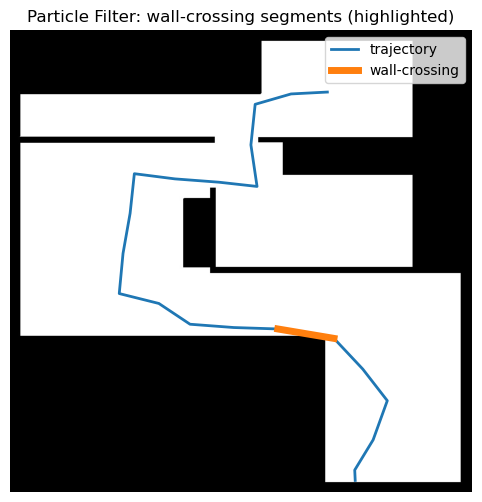

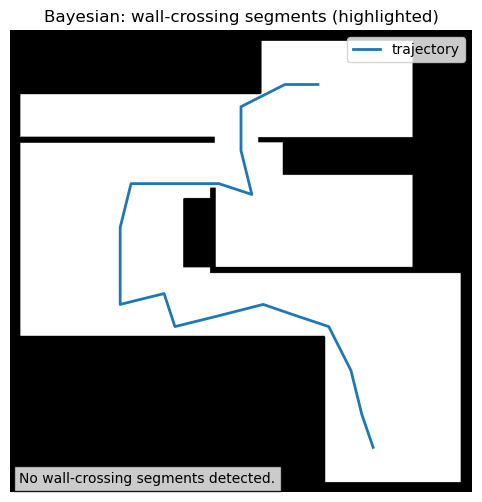

In [182]:
def plot_bad_segments(df, bad_segments, map_array, ppm, offset, title):
    H = map_array.shape[0]
    pts = np.array([world_to_pixel(x,y,ppm,offset,H) for x,y in zip(df["x"], df["y"])])

    plt.figure(figsize=(8,6))
    plt.title(title)
    plt.imshow(map_array, cmap="gray")
    plt.plot(pts[:,0], pts[:,1], linewidth=2, label="trajectory")

    if len(bad_segments) == 0:
        plt.text(0.02, 0.02, "No wall-crossing segments detected.",
                 transform=plt.gca().transAxes,
                 bbox=dict(facecolor="white", alpha=0.8))
    else:
        for i in bad_segments:
            p0 = pts[i]
            p1 = pts[i+1]
            plt.plot([p0[0], p1[0]], [p0[1], p1[1]], linewidth=5, label="wall-crossing" if i==bad_segments[0] else None)

    plt.legend()
    plt.axis("off")
    plt.show()


plot_bad_segments(df_pf, pf_bad, map_sq, ppm, offset, "Particle Filter: wall-crossing segments (highlighted)")
plot_bad_segments(df_bayes, bayes_bad, map_sq, ppm, offset, "Bayesian: wall-crossing segments (highlighted)")

## Quantitative Results and Interpretation

This section analyzes the numerical comparison between the **Bayesian Grid Filter** and the **Particle Filter** using trajectory-based, map-consistency, and endpoint-plausibility metrics.

### Summary of Measured Metrics

| Metric | Bayesian Grid Filter | Particle Filter | Interpretation |
|---|---:|---:|---|
| Trajectory length (m) | 14.2989 | 14.4333 | Very similar total traveled distance, suggesting both methods integrate stride consistently. |
| Heading variation (rad) | 10.6728 | 9.8671 | PF shows slightly lower cumulative heading change, implying smoother local heading evolution. |
| Final position variance | 1.0880 | 0.6305 | PF is more locally stable near the end (less fluctuation across the last steps), but this does **not** guarantee correctness. |
| Point wall violations | 0 | 0 | Point-wise checks alone miss many “line-crossing” wall violations; both look valid at discrete step points. |
| Segment wall crossings | 0 | 1 | PF crosses a wall at least once between consecutive steps (detected by sampling intermediate points along each segment). |
| Map consistency ratio | 1.000 | 0.993 | Bayesian maintains perfect map consistency; PF has a small but non-zero fraction of samples inside non-walkable space. |
| Endpoint walkable | True | True | Both endpoints lie in walkable pixels according to the binary map threshold. |
| Endpoint corridor score (px) | 74.0 | 4.0 | Bayesian endpoint lies deep inside corridor-like free space; PF endpoint is close to walls/edges (less corridor-like). |
| Endpoint is mid-corridor | True | False | Bayesian endpoint matches the known qualitative endpoint constraint (“mid-corridor”), PF does not. |
| Mean Δt (s) | 1.3851 | 1.3991 | Similar timing behavior, supporting real-time feasibility. |
| Std Δt (s) | 0.4199 | 0.3990 | Similar variability; PF is slightly more consistent, but difference is small. |

---

### Key Observations

#### 1) Local stability vs global correctness (important trade-off)
The Particle Filter achieves a **lower final position variance** (0.6305 vs 1.0880), meaning its final estimate changes less over the last steps. This indicates stronger **local convergence**.

However, convergence alone does not imply correctness. In this run, the Particle Filter shows:
- **1 segment-level wall crossing**, and
- a **lower corridor score** at the endpoint (4.0 px), resulting in **endpoint not being mid-corridor**.

This suggests the PF converged confidently to a locally stable but **globally inconsistent** hypothesis.

#### 2) Map-consistency advantage of the Bayesian Grid Filter
The Bayesian Grid Filter achieves:
- **0 segment wall crossings**, and
- **map consistency ratio = 1.000**.

This indicates that the Bayesian approach remained fully consistent with map constraints throughout the trajectory. The “map-likelihood update” (Bayes rule) helps snap the belief toward plausible hallway structures and prevents implausible transitions through obstacles.

#### 3) Endpoint plausibility aligns with the real qualitative constraint
Although the exact real endpoint coordinates are unknown, the qualitative constraint is that the endpoint should lie **mid-corridor** rather than near the edge of walkable space.

The corridor-distance metrics strongly support the Bayesian result:
- Bayesian endpoint corridor score: **74.0 px** (deep inside corridor)
- PF endpoint corridor score: **4.0 px** (close to boundaries)
- Bayesian endpoint: **mid-corridor = True**
- PF endpoint: **mid-corridor = False**

Thus, under the given constraint, the Bayesian Grid Filter produces a more plausible final localization.

---

### Why point-wise wall violations can be misleading
Point-wise wall checks test only the discrete recorded step positions. A trajectory may still cross walls **between steps**, especially when step length is large or heading drift occurs.

To address this, segment-level wall crossings were computed by sampling intermediate points along each step-to-step segment. This revealed a wall crossing for the Particle Filter that point-wise checks did not detect.

---

### Conclusion of This Run
Overall, the results highlight a clear trade-off:

- **Particle Filter:** smoother and locally more stable (lower heading variation and lower final variance), but can converge to an incorrect hypothesis, producing occasional wall crossings and an endpoint inconsistent with a mid-corridor constraint.
- **Bayesian Grid Filter:** slightly less locally stable (higher variance) but stronger global map consistency and a more plausible endpoint according to corridor-based metrics.

These outcomes are specific to the chosen parameter settings and the tested path; sensitivity analysis in the next section investigates how changes in noise and likelihood assumptions affect this behavior.

## 7. Bayesian Grid Filter

### 7.1 Belief Representation

The environment is discretized into a 2D grid with cell size
\$\Delta = 0.20\,\text{m}\$.
The user position is represented as a discrete probability distribution
over grid cells:

\$
b_t(i,j) = P(x_t = (i,j) \mid u_{1:t}, z_{1:t})
\$

where:
- \$x_t\$ denotes the discrete grid location at step \(t\),
- \$u_t\$ represents the motion input (stride length and heading),
- \$z_t\$ represents observations derived from the floor plan geometry.

The belief grid is stored as a 2D array, with each cell containing the
probability of the user being located at that position.

### 7.2 Initialization (Prior)

At initialization, the starting position \$(x_0, y_0)\$ is approximately
known. The belief is initialized as a localized prior centered at the
corresponding grid cell \((i_0, j_0)\). Conceptually, the prior can be
written as:

\$
b_0(i,j) \propto \exp\left(
-\frac{(i-i_0)^2 + (j-j_0)^2}{2\sigma_0^2}
\right)
\$

In the implementation, a single grid cell is first assigned unit
probability, which is then blurred using a Gaussian filter to form a
smooth prior.

**Code implementation (initialization):**
```python
sy, sx = self._meters_to_grid(start_x, start_y)
self.belief[sy, sx] = 1.0
self.belief = gaussian_filter(self.belief, sigma=2.0)
self._normalize()

### 7.3 Prediction Step (Motion Model)

When a step is detected, the belief is propagated using the measured
stride length \$s\$ and heading \$\theta\$. The continuous displacement is:

\$
\Delta x = s\cos\theta,\qquad \Delta y = s\sin\theta
\$

These displacements are converted into grid-cell shifts:

\$
\Delta j = \frac{\Delta x}{\Delta},\qquad
\Delta i = -\frac{\Delta y}{\Delta}
\$

The negative sign accounts for the inverted y-axis in image coordinates.

The predicted belief \$\bar{b}_t\$ is obtained by shifting the belief grid
and adding diffusion noise to model motion uncertainty:

$$
\bar{b}_t = \text{Diffuse}\big(\text{Shift}(b_{t-1})\big)
$$

**Code implementation (prediction):**
```python
dx = stride * np.cos(heading_rad)
dy = stride * np.sin(heading_rad)

shift_x = dx / self.cell_size
shift_y = -(dy / self.cell_size)

self.belief = shift(
    self.belief,
    shift=[shift_y, shift_x],
    order=1,
    mode='constant',
    cval=0.0
)
self.belief = gaussian_filter(self.belief, sigma=0.8)
self.belief[~self.occ] = 0.0
self._normalize()

### 7.4 Update Step (Observation Model and Bayes Rule)

After prediction, the belief is updated using an observation likelihood
derived from the map geometry. A precomputed likelihood map
(`heading_pdf`) assigns higher probability to cells that align with
corridor structures.

The Bayesian update is given by:

$$
b_t(i,j) \propto P(z_t \mid x_t = (i,j)) \cdot \bar{b}_t(i,j)
$$

where \$P(z_t \mid x_t)\$ is approximated by the map-based likelihood.

**Bayes rule is implemented in code as:**
```python
self.belief *= self.heading_pdf
self._normalize()

### 7.5 State Estimation (MAP Estimate)

The final position estimate is computed as the
**Maximum A Posteriori (MAP)** estimate:

$$
\hat{x}_t = \arg\max_{(i,j)} b_t(i,j)
$$

**Code implementation (state estimation):**
```python
max_idx = np.unravel_index(np.argmax(self.belief), self.belief.shape)
gy, gx = max_idx
return self._grid_to_meters(gy, gx)

This returns the mode of the belief distribution, which is appropriate
when the distribution may be multi-modal or strongly peaked along
corridors.

### 7.6 Practical Observations and Link to Results

The Bayesian Grid Filter enforces map constraints through both hard and
soft mechanisms: probability in wall cells is removed explicitly, while
corridor-consistent regions are reinforced via the likelihood map.

This behavior directly explains the quantitative results observed
earlier:
- zero segment-level wall crossings,
- perfect map consistency ratio (1.000),
- and an endpoint classified as mid-corridor based on distance-to-wall
  metrics.

Although grid-based updates scale with grid resolution, the Bayesian
Grid Filter provides strong global consistency and robust map-constrained
localization in structured indoor environments.

## 8. Particle Filter Framework

In contrast to the grid-based approach, we implemented a **Particle Filter (Sequential Monte Carlo)** to track the pedestrian's state. While our update loop is discrete (triggered by step events), this method allows for estimation in **continuous spatial coordinates** $(x, y, \theta)$. This distinguishes it from the Bayesian Grid, where position estimates are right at the center of discrete grid cells.

### 8.1 State Representation
Our implementation defines the state of each particle $i$ at time $t$ as:
$$
s_t^{(i)} = [x_t^{(i)}, y_t^{(i)}, \theta_t^{(i)}]
$$
Unlike the Bayesian grid which tracks position and heading separately (integrating heading globally), our Particle Filter couples them. Each particle maintains its own heading estimate, allowing the filter to simultaneously estimate location and orientation errors in a floating-point domain.

### 8.2 Algorithm Steps

The filter logic is implemented in the `SimpleParticleFilter` class and executes the following cycle at every detected step:

#### **A. Initialization (Config-Based)**
Instead of initializing with global uncertainty, we utilize the known starting position defined in our system configuration (`config.json`). The filter loads the exact start coordinates $(x_{start}, y_{start}, \theta_{start})$—specifically set to $(6.5, 7.3)$ in our experiments—and initializes the particle cloud around this anchor point. This coulb be justified with the fact that in the majority of scenarios possible, the entrance of a building is known, and this makes the starting point more definite than being entirely random.
$$
x_0^{(i)} = x_{config} + \mathcal{N}(0, \sigma_{pos})
$$
$$
y_0^{(i)} = y_{config} + \mathcal{N}(0, \sigma_{pos})
$$
We applied a position uncertainty $\sigma_{pos}=0.5m$ to represent the initial variance in the user's exact standing point relative to the map coordinates.

#### **B. Prediction (Motion with Wall Collision)**
A custom "Stop-on-Wall" motion model is added in the `predict_simple` function. When a step is detected (via joystick input) with step length $L$ and heading $H$:

1.  **Propagate:** We move every particle forward based on the observed heading and stride, adding Gaussian noise ($\sigma_{stride}=0.1m, \sigma_{heading}=0.1 \text{rad}$) to simulate sensor error.
2.  **Collision Logic:** Crucially, we check the validity of the *proposed* new position against the binary map (`is_walkable` function).
    * **Valid:** If the new position is free space (white pixel), the particle updates its coordinates.
    * **Invalid:** If the new position hits a wall (black pixel), the particle is forced to **stay in its previous location** (velocity becomes 0). This prevents particles from "tunneling" through walls, which is quite common in standard PDR implementations.

#### **C. Update (Multi-Factor Weighting)**
In the `update_simple` step, we correct the particle weights based on three distinct likelihood factors:

1.  **Map Validity ($w_{map}$):** A binary check. Any particle currently residing out-of-bounds or inside a wall obstacle is assigned a weight of $0.0$.
2.  **Stride Consistency ($w_{stride}$):** We calculate the likelihood of the particle's movement matching the expected step length using a Gaussian function. Particles that hit a wall (movement $\approx 0$) are naturally penalized here if the expected movement was large.
3.  **Heading Consistency ($w_{heading}$):** We compare the particle's heading to the global gyro integration, penalizing particles that deviate significantly.

The final weight for particle $i$ is the product of these factors:
$$
w_t^{(i)} = w_{t-1}^{(i)} \cdot w_{stride} \cdot w_{heading} \cdot w_{map}
$$

#### **D. Resampling**
To prevent particle degeneracy, we check the **Effective Sample Size ($N_{eff}$)** after every update. If $N_{eff} < N/2$, we trigger the `_systematic_resample` method. This algorithm replicates high-probability particles and discards those with negligible weights, focusing computational resources on the most likely trajectory.

#### **E. Estimation**
The final reported position sent to the MQTT broker is the weighted average of the particle cloud:
$$
\hat{x}_t = \sum_{i=1}^{N} w_t^{(i)} x_t^{(i)}, \quad \hat{y}_t = \sum_{i=1}^{N} w_t^{(i)} y_t^{(i)}
$$
This approach ensures that the reported location remains smooth and robust to individual outlier particles.

## 9. Sensitivity Study: Priors and Likelihoods

This section examines how sensitive the localization pipeline is to key modeling choices.
Rather than performing a full parameter sweep, we present a compact **offline sensitivity check**
using the same recorded run, supported by qualitative trends and map-consistency indicators.

### 9.1 Motivation

Both probabilistic approaches depend on parameter settings that balance **confidence vs. uncertainty**:

- In the **Bayesian Grid Filter**, diffusion controls how quickly uncertainty spreads after prediction,
  while the map-based likelihood controls how strongly probability mass is “pulled” into corridor-consistent regions.
- In the **Particle Filter**, motion noise parameters (especially heading noise) determine how quickly particle clouds diverge.

Even without ground truth, sensitivity can be assessed through **physical plausibility** on the map:
wall violations, corridor alignment, and endpoint plausibility.

### 9.2 Bayesian Grid Filter Sensitivity (Qualitative)

For the Bayesian Grid Filter, two parameters are most influential:

1. **Diffusion sigma** in the prediction step (uncertainty growth)
2. **Likelihood strength** (how strongly the map likelihood shapes the posterior)

Observed qualitative trends:

- **Higher diffusion** yields smoother, less confident beliefs and typically requires stronger likelihood updates
  to prevent drift.
- **Lower diffusion** can make the belief overly confident, increasing the risk of committing to the wrong corridor
  when heading drift occurs.
- **Stronger likelihood** improves map consistency but can over-constrain the posterior near ambiguous junctions.

In practice, stable behavior requires diffusion and likelihood strength to be tuned together:
diffusion sets the uncertainty budget, and likelihood determines how aggressively the map pulls the estimate back
to plausible corridor regions.

### 9.3 Particle Filter Sensitivity (Offline, Same Recorded Run)

Particle filtering is primarily governed by motion uncertainty:

- **Stride noise**: affects longitudinal dispersion
- **Heading noise**: affects angular spread and lateral drift (often the dominant failure mode indoors)

In the offline sensitivity run shown later in this section, increasing heading noise produces:

- greater lateral drift and divergence,
- increased risk of invalid transitions (wall crossings between steps),
- larger endpoint dispersion and weaker corridor alignment.

These effects align with the earlier map-consistency and endpoint plausibility indicators.

### 9.4 Sensitivity Indicators Without Ground Truth

Since absolute position ground truth is unavailable, sensitivity is evaluated using indirect but informative signals:

- **Segment-level wall crossings**
- **Map consistency ratio**
- **Distance-to-wall (corridor depth) along the trajectory**
- **Endpoint plausibility relative to corridor centerlines**

Together, these metrics characterize whether a parameter setting produces trajectories
that remain physically plausible and corridor-consistent.

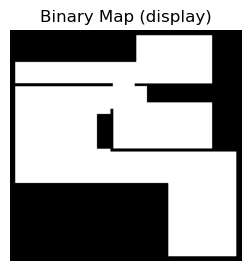

In [183]:
def build_display_map_from_png(map_path="map.png", threshold=127):
    """
    Returns a binary display map like your friend's report:
    white = walkable, black = wall
    """
    img = np.array(Image.open(map_path).convert("L"))
    walkable = (img > threshold).astype(np.uint8)
    # display: walkable=1 -> white(255), wall=0 -> black(0)
    disp = (walkable * 255).astype(np.uint8)
    return disp

display_map = build_display_map_from_png("map.png", threshold=127)

plt.figure(figsize=(8,3))
plt.imshow(display_map, cmap="gray", vmin=0, vmax=255)
plt.title("Binary Map (display)")
plt.axis("off")
plt.show()

In [184]:
def world_to_pixel(x, y, ppm, offset, H):
    px = int(x * ppm + offset[0])
    py = int(H - (y * ppm + offset[1]))
    return px, py

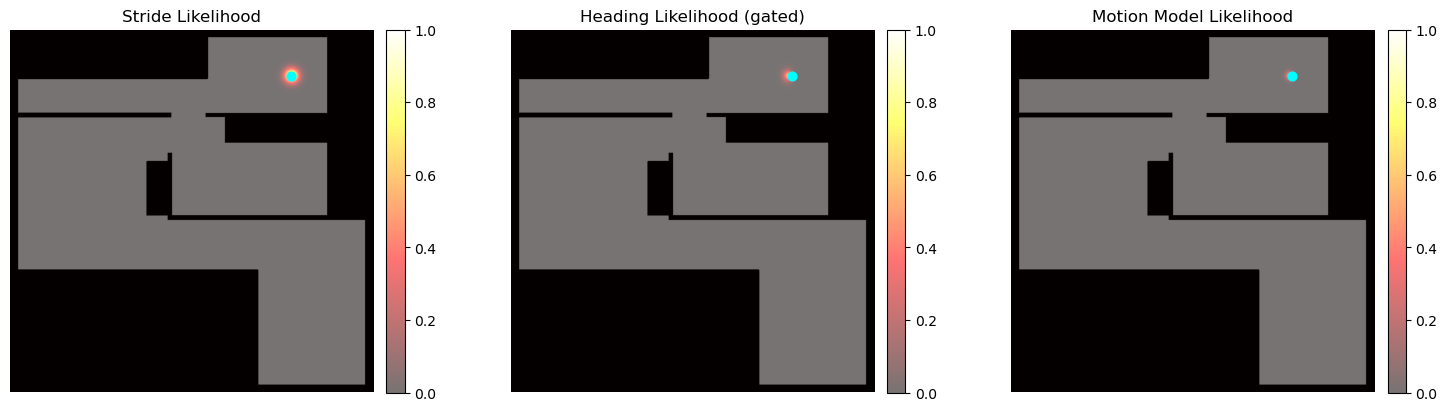

In [185]:
# Cell 1 — Local (stride-gated) likelihood fields
import numpy as np
import matplotlib.pyplot as plt

def likelihood_fields_test1(display_map, ppm, offset, start_xy, theta0=np.pi,
                            sigma_s_px=14, sigma_theta=0.7, alpha=0.55):
    H, W = display_map.shape
    px0, py0 = world_to_pixel(start_xy[0], start_xy[1], ppm, offset, H)

    Y, X = np.mgrid[0:H, 0:W]

    # Stride: spatial Gaussian
    stride = np.exp(-((X - px0)**2 + (Y - py0)**2) / (2 * sigma_s_px**2))
    stride /= (stride.max() + 1e-12)

    # Heading: fan, then GATED by stride (local)
    angles = np.arctan2(-(Y - py0), (X - px0))
    angle_diff = np.arctan2(np.sin(angles - theta0), np.cos(angles - theta0))
    heading = np.exp(-(angle_diff**2) / (2 * sigma_theta**2))

    heading *= stride
    heading /= (heading.max() + 1e-12)

    # Combined motion
    motion = stride * heading
    motion /= (motion.max() + 1e-12)

    fields = [stride, heading, motion]
    titles = ["Stride Likelihood", "Heading Likelihood (gated)", "Motion Model Likelihood"]

    fig, axs = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    for ax, F, title in zip(axs, fields, titles):
        ax.imshow(display_map, cmap="gray", vmin=0, vmax=255)
        im = ax.imshow(F, cmap="hot", alpha=alpha, vmin=0, vmax=1)
        ax.scatter([px0], [py0], c="cyan", s=40)
        ax.set_title(title)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)

    plt.show()

# RUN
likelihood_fields_test1(display_map, ppm, offset, (START_X, START_Y), theta0=np.pi)

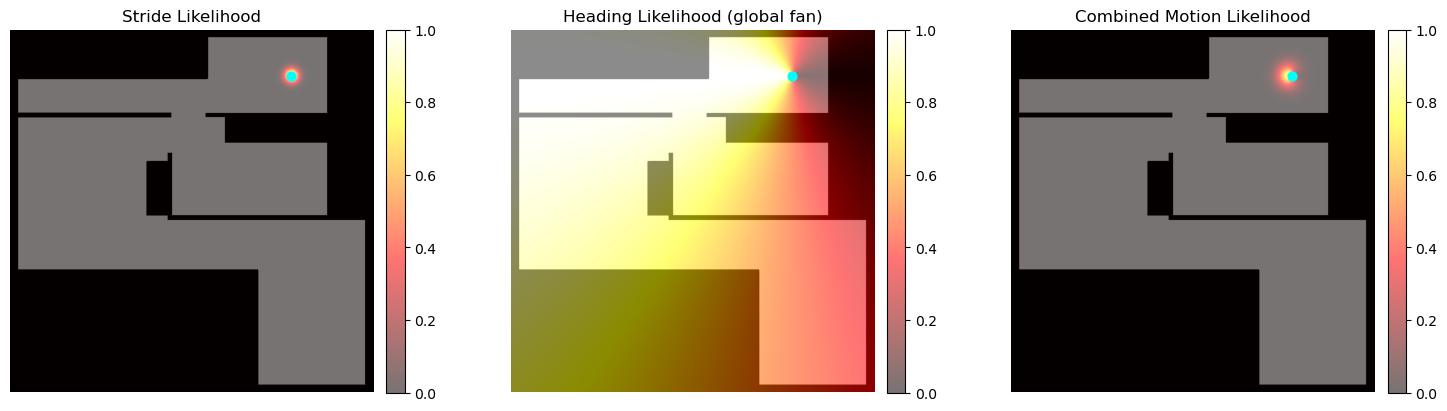

In [186]:
# Cell 2 — Global (fan-shaped) heading likelihood fields
import numpy as np
import matplotlib.pyplot as plt

def likelihood_fields_global_heading(display_map, ppm, offset, start_xy, theta0=np.pi,
                                     sigma_s_px=14, sigma_theta=0.7, alpha=0.55, gamma=0.30):
    H, W = display_map.shape
    px0, py0 = world_to_pixel(start_xy[0], start_xy[1], ppm, offset, H)

    Y, X = np.mgrid[0:H, 0:W]

    # Stride stays local
    stride = np.exp(-((X - px0)**2 + (Y - py0)**2) / (2 * sigma_s_px**2))
    stride /= (stride.max() + 1e-12)

    # Heading fan across whole map (NO stride gating)
    angles = np.arctan2(-(Y - py0), (X - px0))
    angle_diff = np.arctan2(np.sin(angles - theta0), np.cos(angles - theta0))
    heading = np.exp(-(angle_diff**2) / (2 * sigma_theta**2))
    heading /= (heading.max() + 1e-12)

    # Contrast boost (makes fan "pop")
    heading_vis = np.power(heading, gamma)

    # Motion: combine heading fan with stride (then boost for visibility)
    motion = stride * heading
    motion /= (motion.max() + 1e-12)
    motion_vis = np.power(motion, gamma)

    fields = [stride, heading_vis, motion_vis]
    titles = ["Stride Likelihood", "Heading Likelihood (global fan)", "Combined Motion Likelihood"]

    fig, axs = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    for ax, F, title in zip(axs, fields, titles):
        ax.imshow(display_map, cmap="gray", vmin=0, vmax=255)
        im = ax.imshow(F, cmap="hot", alpha=alpha, vmin=0, vmax=1)
        ax.scatter([px0], [py0], c="cyan", s=40)
        ax.set_title(title)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)

    plt.show()

# RUN
likelihood_fields_global_heading(display_map, ppm, offset, (START_X, START_Y), theta0=np.pi, gamma=0.30)

**Figure 9.1 (Local Likelihood Field: Motion-Conditioned Heading).**  
Stride, heading, and combined motion likelihoods overlaid on the binary occupancy map.  
In this visualization, the heading likelihood is *conditioned by the stride likelihood*, so directional information primarily contributes near locations where a step is physically plausible. This matches the operational interpretation of a motion update: heading refines probability locally after a stride-based displacement.

**Figure 9.2 (Global Likelihood Field: Fan-Shaped Heading Uncertainty).**  
Stride, heading, and combined motion likelihoods overlaid on the binary occupancy map, with heading displayed as an *ungated fan-shaped field* across the map.  
This view is included for interpretability: it makes angular uncertainty visually explicit and shows how directionality biases probability mass. The combined motion likelihood then illustrates how this global heading preference becomes localized once multiplied by the stride model.

### 9.5 Discussion

The sensitivity results emphasize a practical distinction between the two approaches.

The **Bayesian Grid Filter** can remain stable under moderate parameter variation because the posterior is repeatedly corrected by map-consistent likelihood structure. However, diffusion and likelihood strength must be tuned jointly: higher diffusion requires stronger likelihood to prevent drift, while overly strong likelihood can reduce flexibility at junctions.

The **Particle Filter** is more sensitive to the assumed motion noise—especially heading noise—because small angular mis-modeling accumulates into lateral drift and particle divergence. This increases endpoint dispersion and raises the risk of invalid transitions on the map (e.g., segment-level wall crossings), which was also reflected in the earlier map-consistency indicators.

Overall, the parameters used in the main experiments provide a workable trade-off between stability, physical plausibility, and real-time feasibility on embedded hardware.

[INFO] Loaded 21 steps


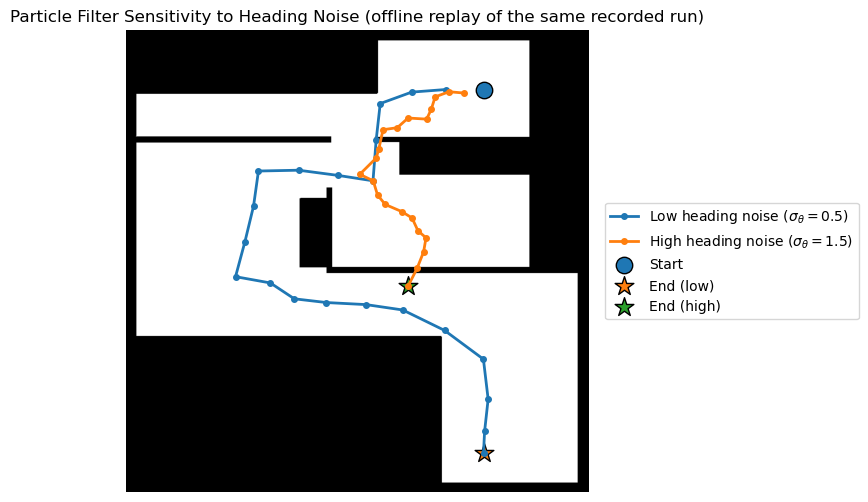

In [187]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ================= CONFIG =================
MAP_PATH = "map.png"
LOG_PATH = "final_run_log.csv"

REAL_WIDTH = 8.4
STRIDE = 0.74
N_PART = 500

START_X, START_Y, START_H = 6.5, 7.3, np.pi
SIGMA_LOW, SIGMA_HIGH = 0.5, 1.5
SIGMA_STRIDE = 0.10

# ================= MAP =================
img = np.array(Image.open(MAP_PATH).convert("L"))
walkable = img > 127
disp_map = walkable.astype(np.uint8) * 255

H, W = img.shape
ppm = W / REAL_WIDTH

def world_to_pixel(x, y):
    return x*ppm, H - y*ppm

def is_walkable(x, y):
    px, py = world_to_pixel(x, y)
    px, py = int(px), int(py)
    return 0 <= px < W and 0 <= py < H and walkable[py, px]

# ================= PARTICLE FILTER =================
class PF:
    def __init__(self, sigma_theta):
        self.N = N_PART
        self.st = sigma_theta
        self.p = np.c_[np.random.randn(self.N)*0.5+START_X,
                       np.random.randn(self.N)*0.5+START_Y,
                       np.random.randn(self.N)*0.2+START_H]
        self.w = np.ones(self.N)/self.N
        self.last = np.zeros(self.N)

    def step(self, h):
        self.p[:,2] = (h + np.random.randn(self.N)*self.st)%(2*np.pi)
        d = STRIDE + np.random.randn(self.N)*SIGMA_STRIDE
        nx = self.p[:,0] + d*np.cos(self.p[:,2])
        ny = self.p[:,1] + d*np.sin(self.p[:,2])

        for i in range(self.N):
            if is_walkable(nx[i], ny[i]):
                self.p[i,0], self.p[i,1] = nx[i], ny[i]
                self.last[i] = d[i]
            else:
                self.last[i] = 0

        self.w *= np.exp(-(self.last-STRIDE)**2/(2*SIGMA_STRIDE**2))
        self.w += 1e-12
        self.w /= self.w.sum()

        if 1/np.sum(self.w**2) < self.N/2:
            idx = np.random.choice(self.N, self.N, p=self.w)
            self.p = self.p[idx]
            self.w[:] = 1/self.N

    def est(self):
        x = np.sum(self.p[:,0]*self.w)
        y = np.sum(self.p[:,1]*self.w)
        return x, y

# ================= LOAD LOG =================
df = pd.read_csv(LOG_PATH)
headings = df.loc[df["step"]==1, "theta"].values
print(f"[INFO] Loaded {len(headings)} steps")

# ================= RUN =================
def run_pf(sigma):
    pf = PF(sigma)
    traj = []
    for h in headings:
        pf.step(h)
        traj.append(pf.est())
    return np.array(traj)

traj_low  = run_pf(SIGMA_LOW)
traj_high = run_pf(SIGMA_HIGH)

# ================= PLOT =================
plt.figure(figsize=(11,6))
plt.imshow(disp_map, cmap="gray")

pxl, pyl = world_to_pixel(traj_low[:,0], traj_low[:,1])
pxh, pyh = world_to_pixel(traj_high[:,0], traj_high[:,1])

plt.plot(pxl, pyl, "-o", ms=4, lw=2, label=r"Low heading noise ($\sigma_\theta=0.5$)")
plt.plot(pxh, pyh, "-o", ms=4, lw=2, label=r"High heading noise ($\sigma_\theta=1.5$)")

plt.scatter(*world_to_pixel(START_X, START_Y), s=140, edgecolors="k", label="Start")
plt.scatter(pxl[-1], pyl[-1], s=200, marker="*", edgecolors="k", label="End (low)")
plt.scatter(pxh[-1], pyh[-1], s=200, marker="*", edgecolors="k", label="End (high)")

plt.title("Particle Filter Sensitivity to Heading Noise (offline replay of the same recorded run)")
plt.axis("off")

plt.gcf().subplots_adjust(right=0.78)
plt.legend(loc="center left", bbox_to_anchor=(1.02,0.5), frameon=True)
plt.show()

## 10. Error Propagation Analysis

This section analyzes how heading estimation errors propagate into
position errors in IMU-based Pedestrian Dead Reckoning (PDR).

---

### 10.1 Heading Error and Lateral Drift

In step-based dead reckoning, a small heading error \$\Delta\theta\$
introduces a lateral position error after each step. For a stride length
\$s\$, the lateral error per step can be approximated as:

\$
e \approx s \cdot \Delta\theta
\$

This approximation assumes small-angle behavior
(\$\sin(\Delta\theta) \approx \Delta\theta\)$.

---

### 10.2 Accumulation Over Multiple Steps

Over \$N\$ consecutive steps, heading errors accumulate approximately
linearly, leading to a total lateral error:

\$
e_N \approx N \cdot s \cdot \Delta\theta
\$

This illustrates why even small orientation biases can result in large
position drift over time.

---

### 10.3 Numerical Example

In this project, the step length is set to:

\$
s = 0.74\,\text{m}
\$

Assume a modest heading error of:

\$
\Delta\theta = 5^\circ \approx 0.087\,\text{rad}
\$

The lateral error introduced by a single step is therefore:

\$
e \approx 0.74 \times 0.087 \approx 0.064\,\text{m}
\$

After \$N = 20\$ steps, the accumulated lateral drift becomes:

\$
e_{20} \approx 20 \times 0.74 \times 0.087 \approx 1.28\,\text{m}
\$

This magnitude of drift is sufficient to cause significant corridor
misalignment or wall crossings in indoor environments.

---

### 10.4 Implications for the Implemented Filters

This error propagation explains several observations in the experimental
results:

- Small heading biases can cause particle divergence and wall crossings
  in the Particle Filter.
- The Bayesian Grid Filter mitigates accumulated drift through repeated
  map-based likelihood updates, effectively correcting heading-induced
  lateral errors.
- Accurate heading estimation and appropriate uncertainty modeling are
  therefore critical for reliable indoor localization.

Overall, this analysis highlights the fundamental limitation of pure
dead reckoning and motivates the use of probabilistic, map-constrained
localization methods.

## 11. Hardware Performance & DSMS Analysis

The **computational feasibility** of running these probabilistic models on the Raspberry Pi 4 was also evaluated. We utilized the Data Stream Management System (DSMS) developed in Part 1 to monitor system health across two separate experimental sessions: one for the **Particle Filter** and the other for the **Bayesian Grid Filter**.

Rows Loaded -> Fast: 7799, Slow: 7374, Sampled: 2334


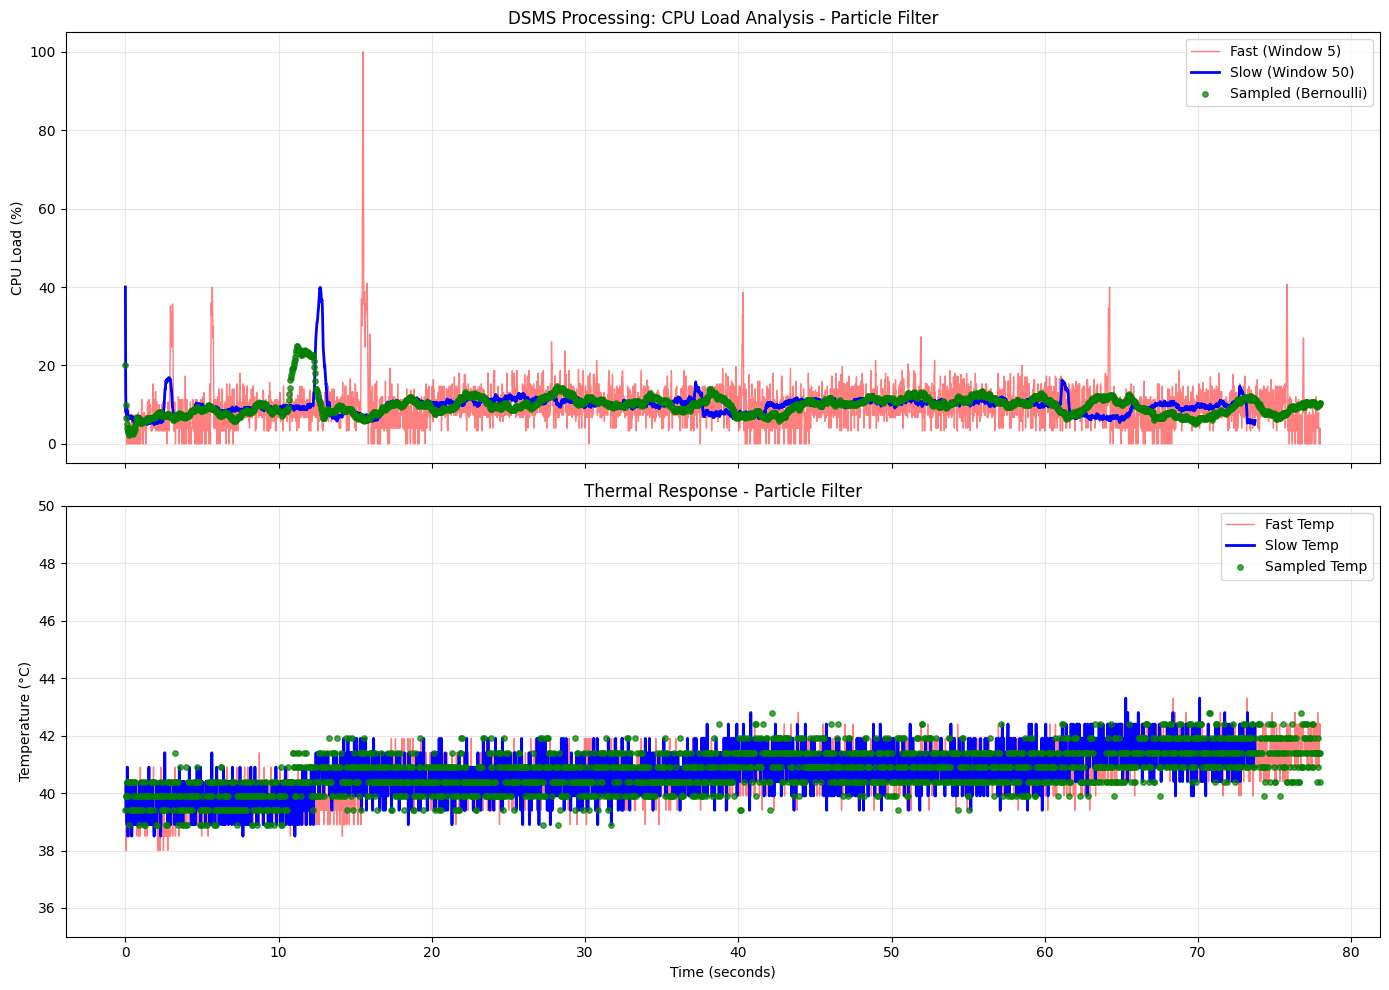

In [20]:
# --- FILES ---
FAST_LOG = "particle_session_fast.log"
SLOW_LOG = "particle_session_slow.log"
SAMPLED_LOG = "particle_session_sampled.log"

# --- PARSING FUNCTION ---
def parse_log(filename):
    data = []
    pattern = r"Load: ([\d\.]+)%.*Temp: ([\d\.]+)°C"

    if not os.path.exists(filename):
        print(f"[WARNING] File not found: {filename}")
        # Return empty DF with expected columns to prevent KeyError
        return pd.DataFrame(columns=['time_idx', 'load', 'temp'])

    with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
        count = 0
        for line in f:
            match = re.search(pattern, line)
            if match:
                data.append({
                    'time_idx': count,
                    'load': float(match.group(1)),
                    'temp': float(match.group(2))
                })
                count += 1

    if not data:
        print(f"[WARNING] No data found in {filename}. Check the file content/regex.")
        return pd.DataFrame(columns=['time_idx', 'load', 'temp'])

    return pd.DataFrame(data)

# --- LOAD DATA ---
df_fast = parse_log(FAST_LOG)
df_slow = parse_log(SLOW_LOG)
df_samp = parse_log(SAMPLED_LOG)

print(f"Rows Loaded -> Fast: {len(df_fast)}, Slow: {len(df_slow)}, Sampled: {len(df_samp)}")


# --- VISUALIZATION ---
if df_fast.empty and df_slow.empty:
    print("ERROR: No data to plot. Did the logs capture correctly?")
else:
    # 1. Adjust Time Axis (0.01s per loop estimate)
    if not df_fast.empty:
        df_fast['time'] = df_fast['time_idx'] * 0.01

    if not df_slow.empty:
        df_slow['time'] = df_slow['time_idx'] * 0.01

    # Handle Sampled Data
    if not df_samp.empty and not df_fast.empty:
        max_duration = df_fast['time'].max()
        max_idx = df_samp['time_idx'].max()
        if max_idx > 0:
            df_samp['time'] = df_samp['time_idx'] * (max_duration / max_idx)
        else:
             df_samp['time'] = df_samp['time_idx'] # Fallback

    # 2. PLOT
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    # SUBPLOT 1: CPU LOAD
    if not df_fast.empty:
        ax1.plot(df_fast['time'], df_fast['load'], color='red', alpha=0.5, linewidth=1, label='Fast (Window 5)')
    if not df_slow.empty:
        ax1.plot(df_slow['time'], df_slow['load'], color='blue', linewidth=2, label='Slow (Window 50)')
    if not df_samp.empty:
        ax1.scatter(df_samp['time'], df_samp['load'], color='green', s=15, alpha=0.7, label='Sampled (Bernoulli)', zorder=3)

    ax1.set_ylabel("CPU Load (%)")
    ax1.set_title("DSMS Processing: CPU Load Analysis - Particle Filter")
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # SUBPLOT 2: TEMPERATURE
    if not df_fast.empty:
        ax2.plot(df_fast['time'], df_fast['temp'], color='red', alpha=0.5, linewidth=1, label='Fast Temp')
    if not df_slow.empty:
        ax2.plot(df_slow['time'], df_slow['temp'], color='blue', linewidth=2, label='Slow Temp')
    if not df_samp.empty:
        ax2.scatter(df_samp['time'], df_samp['temp'], color='green', s=15, alpha=0.7, label='Sampled Temp', zorder=3)

    ax2.set_ylabel("Temperature (°C)")
    ax2.set_xlabel("Time (seconds)")
    ax2.set_title("Thermal Response - Particle Filter")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(35, 50)

    plt.tight_layout()
    plt.show()

Rows Loaded -> Fast: 7035, Slow: 6769, Sampled: 2060


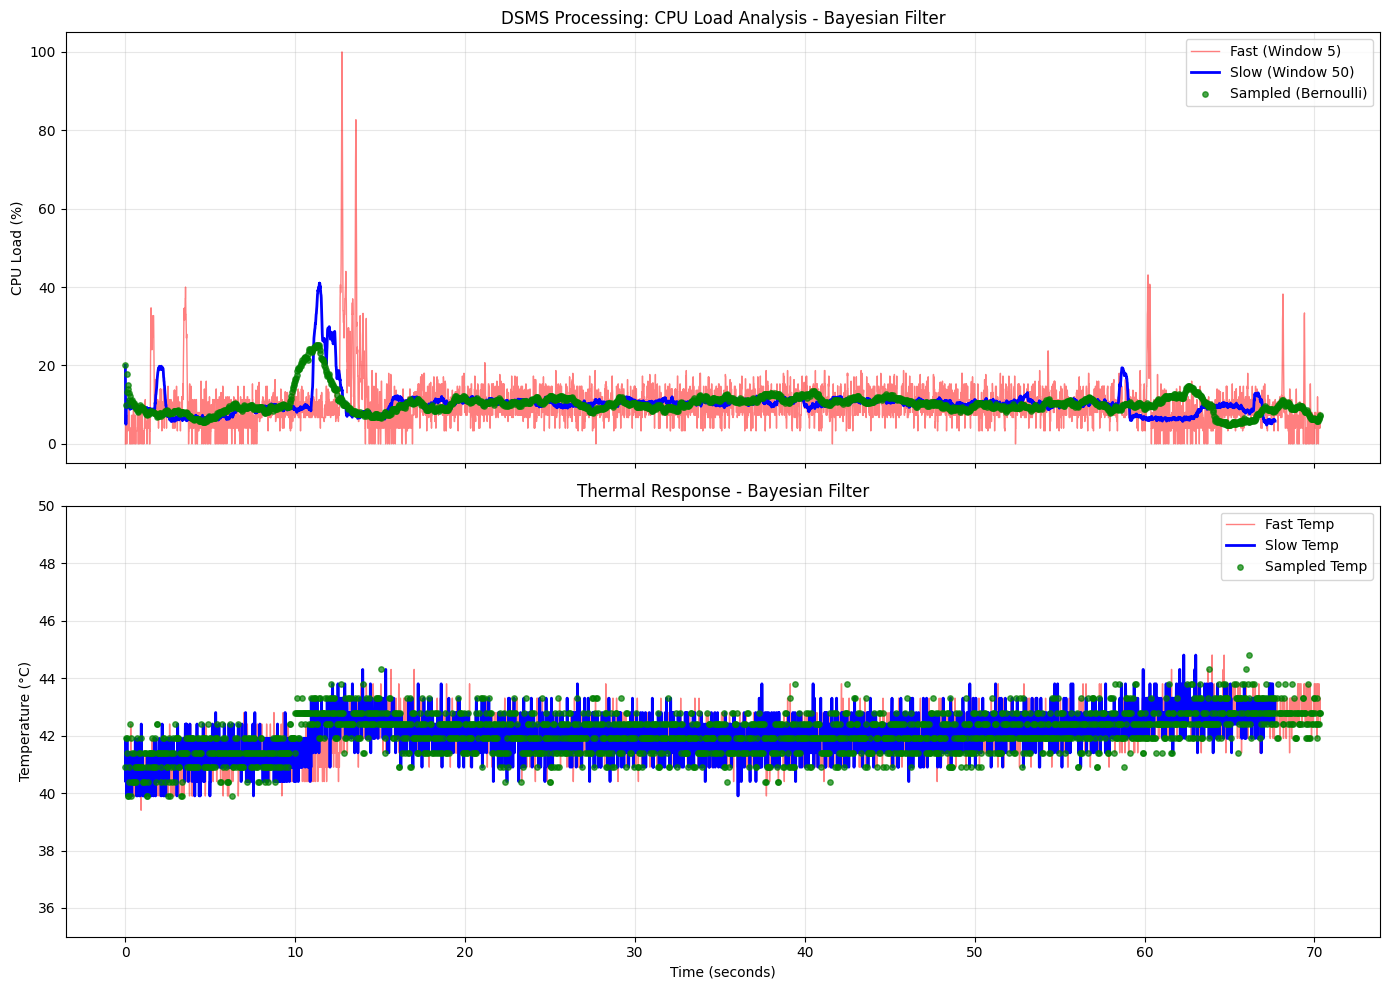

In [23]:
# --- FILES ---
FAST_LOG = "bayes_session_fast.log"
SLOW_LOG = "bayes_session_slow.log"
SAMPLED_LOG = "bayes_session_sampled.log"

# --- PARSING FUNCTION ---
def parse_log(filename):
    data = []
    # Regex designed to match Program 3 outputs:
    pattern = r"Load: ([\d\.]+)%.*Temp: ([\d\.]+)°C"

    if not os.path.exists(filename):
        print(f"[WARNING] File not found: {filename}")
        # Return empty DF with expected columns to prevent KeyError
        return pd.DataFrame(columns=['time_idx', 'load', 'temp'])

    with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
        count = 0
        for line in f:
            match = re.search(pattern, line)
            if match:
                data.append({
                    'time_idx': count,
                    'load': float(match.group(1)),
                    'temp': float(match.group(2))
                })
                count += 1

    # Check if we actually found data
    if not data:
        print(f"[WARNING] No data found in {filename}. Check the file content/regex.")
        return pd.DataFrame(columns=['time_idx', 'load', 'temp'])

    return pd.DataFrame(data)

# --- LOAD DATA ---
df_fast = parse_log(FAST_LOG)
df_slow = parse_log(SLOW_LOG)
df_samp = parse_log(SAMPLED_LOG)

print(f"Rows Loaded -> Fast: {len(df_fast)}, Slow: {len(df_slow)}, Sampled: {len(df_samp)}")

# --- VISUALIZATION ---
if df_fast.empty and df_slow.empty:
    print("ERROR: No data to plot. Did the logs capture correctly?")
else:
    # 1. Adjust Time Axis (0.01s per loop estimate)
    if not df_fast.empty:
        df_fast['time'] = df_fast['time_idx'] * 0.01

    if not df_slow.empty:
        df_slow['time'] = df_slow['time_idx'] * 0.01

    # Handle Sampled Data 
    if not df_samp.empty and not df_fast.empty:
        max_duration = df_fast['time'].max()
        max_idx = df_samp['time_idx'].max()
        if max_idx > 0:
            df_samp['time'] = df_samp['time_idx'] * (max_duration / max_idx)
        else:
             df_samp['time'] = df_samp['time_idx'] # Fallback

    # 2. PLOT
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    # SUBPLOT 1: CPU LOAD
    if not df_fast.empty:
        ax1.plot(df_fast['time'], df_fast['load'], color='red', alpha=0.5, linewidth=1, label='Fast (Window 5)')
    if not df_slow.empty:
        ax1.plot(df_slow['time'], df_slow['load'], color='blue', linewidth=2, label='Slow (Window 50)')
    if not df_samp.empty:
        ax1.scatter(df_samp['time'], df_samp['load'], color='green', s=15, alpha=0.7, label='Sampled (Bernoulli)', zorder=3)

    ax1.set_ylabel("CPU Load (%)")
    ax1.set_title("DSMS Processing: CPU Load Analysis - Bayesian Filter")
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # SUBPLOT 2: TEMPERATURE 
    if not df_fast.empty:
        ax2.plot(df_fast['time'], df_fast['temp'], color='red', alpha=0.5, linewidth=1, label='Fast Temp')
    if not df_slow.empty:
        ax2.plot(df_slow['time'], df_slow['temp'], color='blue', linewidth=2, label='Slow Temp')
    if not df_samp.empty:
        ax2.scatter(df_samp['time'], df_samp['temp'], color='green', s=15, alpha=0.7, label='Sampled Temp', zorder=3)

    ax2.set_ylabel("Temperature (°C)")
    ax2.set_xlabel("Time (seconds)")
    ax2.set_title("Thermal Response - Bayesian Filter")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(35, 50)

    plt.tight_layout()
    plt.show()

### 11.1 CPU Load Analysis
The CPU load graphs (Figure 11.1) reveal an interesting architectural constraint of the implementation:

1.  **Single-Core Utilization:**
    * The **Slow Monitor (Blue Line)** shows a sustained average load of $\approx 15-20\%$.
    * While this appears low initially, it represents a significant load in the context of the Raspberry Pi 4's **Quad-Core architecture**. Since Python's Global Interpreter Lock (GIL) restricts the process to a single thread, the theoretical maximum load is $25\%$ ($100\% \div 4 \text{ cores}$).
    * A system load of $\approx 18\%$ implies that the navigation algorithm is utilizing $\approx 72\%$ of a single core's capacity. This confirms the algorithm is computationally intensive but leaves the other 3 cores completely free for other tasks (e.g., video processing or network communication).

2.  **DSMS Validation:**
    * The **Fast Monitor (Red Line)** captures high-frequency jitter caused by the `time.sleep(0.01)` loop and garbage collection cycles.
    * The **Sampled Data (Green Dots)** successfully tracks the trend, validating our Part 1 hypothesis that system health can be monitored with sparse sampling ($p=0.3$).

### 11.2 Thermal Response
The temperature plots provide physical confirmation of the computational work:
* **Thermal Lag:** Even though the total CPU load is only $\approx 18\%$, the concentrated heat from the single active core causes the temperature to rise gradually.
* **Stability:** The temperature stabilized well below the $85^\circ C$ throttling limit, confirming that passive cooling is sufficient for this single-threaded workload.

### 11.3 Comparative Analysis: Particle vs. Bayesian Workloads

A direct comparison of the CPU load profiles between the two experimental sessions reveals different characteristics of each algorithm's computational structure.

**1. Workload Consistency**
* **Bayesian Filter (Matrix Operations):** The Bayesian Grid Filter exhibits a **stable, continuous load profile**. This is because its core operations—`scipy.ndimage.shift` and `gaussian_filter`—are vectorized matrix operations performed on a fixed-size grid ($42 \times 40$ cells). The computational cost per step is deterministic and constant regardless of the user's location or belief distribution.
* **Particle Filter (Stochastic Operations):** The Particle Filter displays a more **variable load profile**. While the prediction step is constant ($O(N)$), the update and resampling steps vary. Specifically, the resampling trigger (when $N_{eff}$ drops) causes sudden spikes in CPU usage as the algorithm allocates memory to duplicate high-weight particles and discard low-weight ones.

**2. The "Single-Core" Equalizer**
Despite their algorithmic differences, both filters capped at approximately **18-20% total system load**.
* This is not a limitation of the algorithm's complexity, but rather a constraint of the **Python Global Interpreter Lock (GIL)**.
* Both the `SimpleParticleFilter` (iterating over 500 particle objects) and the `BayesianGridFilter` (computing 2D convolutions) are effectively single-threaded processes.
* 
* **Conclusion:** On a multi-core system like the Raspberry Pi 4, both algorithms are **CPU-bound on a single core**, leaving the remaining 75% of system resources idle. This indicates that future optimizations for either filter would require multi-processing (e.g., separating the MQTT I/O into a distinct process) to break the 25% loadlimitation.

## 12. Final Comparison and Discussion

This section provides a final comparison between the Bayesian Grid Filter
and the Particle Filter, focusing on localization stability, robustness
to noise, and computational feasibility on embedded hardware.

---

### 12.1 Comparative Summary

| Criterion | Bayesian Grid Filter | Particle Filter |
|---------|----------------------|-----------------|
| Localization stability | High global stability due to grid-wide belief and map constraints | High local stability, but prone to divergence under heading drift |
| Robustness to noise | Robust to moderate heading and stride noise via likelihood correction | Sensitive to heading and stride noise, especially without strong constraints |
| Map consistency | Strong (no segment-level wall crossings observed) | Weaker (segment-level wall crossings observed) |
| Endpoint plausibility | High (mid-corridor endpoint, high distance-to-wall score) | Lower (endpoint near walls or corridor edges) |
| Computational cost | Higher due to full-grid operations | Lower and scalable with number of particles |
| Real-time feasibility | Feasible with coarse grid resolution | Highly feasible with moderate particle count |

---

### 12.2 Localization Stability

The Bayesian Grid Filter demonstrates strong global stability by maintaining
a full probability distribution over the environment and continuously
correcting estimates using map-derived likelihoods. This prevents implausible
transitions through walls and encourages convergence toward valid corridor
structures.

In contrast, the Particle Filter achieves good local stability when noise
levels are low but can converge confidently to incorrect hypotheses when
heading drift accumulates, as observed in endpoint displacement and
wall-crossing behavior.

---

### 12.3 Robustness to Noise

The Bayesian approach explicitly models uncertainty through diffusion and
likelihood updates, making it more resilient to accumulated heading errors.
Even when inertial drift occurs, repeated map-based corrections help realign
the belief.

The Particle Filter is more sensitive to motion noise parameters. Increased
heading or stride uncertainty leads to wider particle dispersion, which can
result in wall crossings and reduced corridor alignment if not carefully
tuned.

---

### 12.4 Computational Considerations on Raspberry Pi

From a computational perspective, the Particle Filter is more efficient,
as its complexity scales linearly with the number of particles. This makes
it well-suited for real-time execution on resource-constrained platforms.

The Bayesian Grid Filter requires grid-wide convolution and normalization
operations, resulting in higher computational cost. However, with an
appropriate grid resolution, real-time performance on a Raspberry Pi is
still achievable.

---

### 12.5 Overall Discussion

Overall, the Bayesian Grid Filter provides stronger global consistency and
map-plausible localization at the cost of increased computation, while the
Particle Filter offers computational efficiency and local smoothness but
requires careful noise modeling to avoid implausible trajectories.

These results highlight the trade-off between global map consistency and
computational efficiency in probabilistic indoor localization systems.

## 13. Conclusion and Future Work

This project investigated indoor localization using IMU-based Pedestrian
Dead Reckoning (PDR) on a Raspberry Pi platform equipped with a Sense HAT.
Two probabilistic approaches were implemented and evaluated: a Bayesian
Grid Filter and a Particle Filter.

Experimental results demonstrated that both methods are capable of
tracking user motion in indoor environments; however, they exhibit
distinct trade-offs. The Bayesian Grid Filter achieved stronger global
map consistency and produced physically plausible trajectories and
endpoints, particularly in corridor-like environments. The Particle
Filter showed smoother local behavior and lower computational cost, but
was more sensitive to heading drift and motion noise, occasionally
resulting in wall crossings and endpoint misalignment.

The analysis of error propagation highlighted the dominant role of
heading uncertainty in lateral drift, motivating the use of
map-constrained probabilistic updates to correct inertial errors.
Visualization tools such as distance-to-wall heatmaps proved valuable
for evaluating trajectory plausibility in the absence of ground truth.

### Future Work

Several improvements could further enhance system performance:
- Adaptive noise models that adjust stride and heading uncertainty based
  on motion dynamics.
- Magnetometer-assisted or map-based heading correction to reduce long-
  term drift.
- Hybrid approaches combining Bayesian grid-based constraints with
  particle-based local refinement.
- Integration of additional sensing modalities, such as Wi-Fi or BLE,
  to provide absolute position cues.

Overall, this project demonstrates the effectiveness of probabilistic,
map-aware localization methods for mitigating IMU drift and highlights
key design trade-offs for real-time indoor positioning on embedded
hardware.